# NOTE
All the metrics to be mentioned are normalized to PER test image.

In [18]:
import os

REPO_DIR = "/kaggle/working/ANN2SNN-Conversion"
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/lazylettuce1/ANN2SNN-Conversion.git {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull
os.chdir(REPO_DIR)

Already up to date.


In [19]:
!python3 setup.py install

/usr/local/lib/python3.12/dist-packages/setuptools/dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
!!

        ********************************************************************************
        Please consider removing the following classifiers in favor of a SPDX license expression:

        License :: Other/Proprietary License

        See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
        ********************************************************************************

!!
  self._finalize_license_expression()
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:90: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        This 

In [20]:
import torch
import torchvision
import torch.nn as nn
import spikingjelly
from spikingjelly.activation_based import ann2snn
from tqdm import tqdm
from spikingjelly.activation_based.ann2snn.examples import cnn_mnist as snn 
from spikingjelly.activation_based.ann2snn.sample_models import mnist_cnn
import numpy as np
import matplotlib.pyplot as plt

### **Task 1** is installing all prerequisites correctly so that the following imports run smoothly. (10 marks)

Install the correct version of torch if you wish to use CUDA.

Install the spikingjelly using the setup.py file only and not with pip using the command 'python setup.py install'.

In [21]:
device_used = 'cuda' if torch.cuda.is_available() else 'cpu'
# set Hyperparameters
snn.hyperparameters.T = 20
snn.hyperparameters.batch_size = 100

device =  device_used # use 'cpu' if CUDA not available
download_dataset = True # downloads MNIST
dataset_dir = './spikingjelly/datasets/mnist'
download_model = False # downloads a 3 layer CNN classifier

if download_model:
        print('Downloading SJ-mnist-cnn_model-sample.pth...')
        ann2snn.download_url("https://ndownloader.figshare.com/files/34960191", './SJ-mnist-cnn_model-sample.pth')

model = mnist_cnn.CNN().to(device)
model.load_state_dict(torch.load('SJ-mnist-cnn_model-sample.pth', map_location=device))
print(model)

CNN(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [22]:
# BASELINE
# Create a standard test loader (without CustomLoader)
test_dataset = torchvision.datasets.MNIST(
  root=dataset_dir,
  train=False,
  transform=torchvision.transforms.ToTensor(),
  download=False
)
test_loader = torch.utils.data.DataLoader(
  dataset=test_dataset,
  batch_size=snn.hyperparameters.batch_size,
  shuffle=False
)

# Call snn.val directly with T=None
baseline_acc = snn.val(
  net=model,
  device=device_used,
  train_data_loader=None,
  test_data_loader=test_loader,
  T=None  # Tells val() to run standard continuous ANN inference
)

print(f"Baseline ANN Accuracy: {baseline_acc * 100:.2f}%")


100%|██████████| 100/100 [00:01<00:00, 94.53it/s]

Baseline ANN Accuracy: 98.70%


We see the specification of our CNN, having three Conv blocks with [Conv, BatchNorm2d, ReLU, AvgPool2d] modules.

### **Task 2** is calculating the number of MAC operations in each Conv layer. (10 Marks)


In [23]:
# TASK 2: number of mac operations in each convolutional layer
# Starting input size for MNIST
in_H, in_W = 28, 28
layer_name = ['IFNode0', 'IFNode1', 'IFNode2']
MAC_count = {}
neurons = {}
for i, layer in enumerate(model.network):
    import math
    if isinstance(layer, nn.Conv2d):
        C_in  = layer.in_channels
        C_out = layer.out_channels
        kH, kW = layer.kernel_size   # kernel_size is always stored as a tuple
        sH, sW = layer.stride
        pH, pW = layer.padding

        # out size, since nn.Conv2d doesn't store in or out sizes
        out_H = math.floor((in_H - kH + 2 * pH) / sH) + 1
        out_W = math.floor((in_W - kW + 2 * pW) / sW) + 1
        
        macs = C_in * kH * kW * out_H * out_W * C_out
        neurons[layer_name[i//4]] = out_H * out_W * C_out
        MAC_count[layer_name[i//4]] = macs
        print(f"Layer {i}: Conv2d(Cin={C_in}, Cout={C_out}, k={kH}x{kW}, s={sH}x{sW}, out={out_H}x{out_W})")
        print(f"  MACs: {macs:,}")
        in_H, in_W = out_H, out_W

    elif isinstance(layer, nn.AvgPool2d):
        # AvgPool changes size
        kH = layer.kernel_size
        sH = layer.stride
        pH = layer.padding

        in_H = math.floor((in_H - kH + 2 * pH) / sH) + 1
        in_W = math.floor((in_W - kH + 2 * pH) / sH) + 1
        # (assumes square kernel, which it is here: 2x2)

Layer 0: Conv2d(Cin=1, Cout=32, k=3x3, s=1x1, out=26x26)
  MACs: 194,688
Layer 4: Conv2d(Cin=32, Cout=32, k=3x3, s=1x1, out=11x11)
  MACs: 1,115,136
Layer 8: Conv2d(Cin=32, Cout=32, k=3x3, s=1x1, out=3x3)
  MACs: 82,944


Above MAC values are PER test image.


Below we take the first two Conv blocks (first 8 modules) as a backbone and the rest of the model as the head.

We freeze the backbone, convert the head to an SNN and evaluate using snn.main.


main() has returned the converted model head and also its accuracy for number of timesteps from 1 to T.

1. We provided a conversion algorithm to snn.main. Go to the file spikingjelly\activation_based\ann2snn\examples\cnn_mnist.py to see how this is defined in snn.conversion_job().
2. You should see some commented out code snippets for other possible conversion jobs. 
3. You can make your own conversion job using any one of those and pass it into snn.main()


### **Task 3** is plotting accuracy vs time steps for all the mentioned conversion jobs in one plot. (10 Marks)
Pick the conversion job that gives best results for you. Stick to this algorithm for all further tasks.

In [24]:
def custom_conversion_job(mode_sel):
    print('---------------------------------------------')
    match mode_sel:
        case 0:
            def mode_job(head, train_data_loader):
                print('Converting using max(activation) as scales')
                model_converter = ann2snn.Converter(mode='max', dataloader=train_data_loader)
                return model_converter(head)
            return mode_job
        case 1:
            def mode_job(head, train_data_loader):
                print('Converting using 99.9% max(activation) as scales')
                model_converter = ann2snn.Converter(mode='99.9%', dataloader=train_data_loader)
                return model_converter(head)
            return mode_job
        case 2:
            def mode_job(head, train_data_loader):
                print('Converting using 1/2 max(activation) as scales')
                model_converter = ann2snn.Converter(mode=1.0 / 2, dataloader=train_data_loader)
                return model_converter(head)
            return mode_job
        case 3:
            def mode_job(head, train_data_loader):
                print('Converting using 1/4 max(activation) as scales')
                model_converter = ann2snn.Converter(mode=1.0 / 4, dataloader=train_data_loader)
                return model_converter(head)
            return mode_job
        case _:
            def mode_job(head, train_data_loader):
                # default to 1/4 max(activation) as scales
                print('Converting using 1/4 max(activation) as scales')
                model_converter = ann2snn.Converter(mode=1.0 / 4, dataloader=train_data_loader)
                return model_converter(head)
            return mode_job
    return model_converter(head)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
)

Running conversion with mode_sel=0 (max)
---------------------------------------------
Converting using max(activation) as scales


100%|██████████| 600/600 [00:32<00:00, 18.67it/s]


Simulating...


100%|██████████| 100/100 [00:06<00:00, 15.41it/s]


Best accuracy: 0.9873
[0.1026 0.7353 0.9763 0.9842 0.9862 0.9866 0.9861 0.9858 0.9868 0.9867
 0.9863 0.9867 0.9861 0.9876 0.9866 0.9863 0.9873 0.9863 0.9864 0.9873]

Running conversion with mode_sel=1 (99.9% max)
---------------------------------------------
Converting using 99.9% max(activation) as scales


...

Best accuracy: 0.9872
[0.7354 0.9842 0.9867 0.9858 0.9866 0.9867 0.9875 0.9865 0.9863 0.9872
 0.9866 0.9868 0.9862 0.9868 0.9865 0.9869 0.987  0.9868 0.9871 0.9872]

Running conversion with mode_sel=3 (1/4 max)
---------------------------------------------
Converting using 1/4 max(activation) as scales


100%|██████████| 600/600 [00:32<00:00, 18.59it/s]


Simulating...


100%|██████████| 100/100 [00:06<00:00, 15.37it/s]


Best accuracy: 0.9861
[0.9837 0.9856 0.9854 0.9862 0.9858 0.9865 0.9864 0.9858 0.986  0.986
 0.9863 0.9865 0.9862 0.986  0.9862 0.9863 0.986  0.9859 0.9861 0.9861]


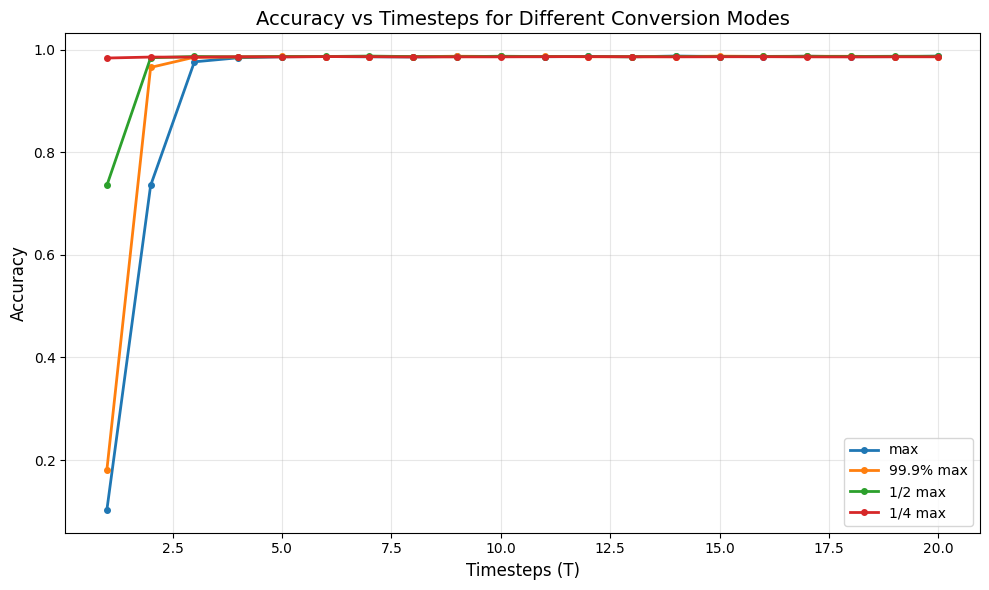


Best conversion mode: 'max' with accuracy 0.9873


In [25]:
# Task 3: Compare different conversion modes
snn.hyperparameters.T = 20
snn.hyperparameters.batch_size = 100
split_index = 8
backbone = model.network[:split_index]
print(backbone)
head = model.network[split_index:]

mode_names = ['max', '99.9% max', '1/2 max', '1/4 max']
mode2acc = {}

for mode_sel in [0, 1, 2, 3]:
    print(f"\n{'='*60}")
    print(f"Running conversion with mode_sel={mode_sel} ({mode_names[mode_sel]})")
    print('='*60)
    
    snn_head, vals = snn.main(
        eval_fn=snn.val, 
        backbone=backbone, 
        head=head,
        conversion=custom_conversion_job(mode_sel), 
        download_dataset=False,
        device=device_used,
        dataset_dir=dataset_dir
    )
    mode2acc[mode_names[mode_sel]] = vals
    print(f"Best accuracy: {vals[-1]:.4f}")
    print(vals)

# Plot accuracy vs timesteps for all modes
plt.figure(figsize=(10, 6))
timesteps = range(1, snn.hyperparameters.T + 1)

for mode_name, vals in mode2acc.items():
    plt.plot(timesteps, vals, marker='o', label=mode_name, linewidth=2, markersize=4)

plt.xlabel('Timesteps (T)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Timesteps for Different Conversion Modes', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_mode = max(mode2acc.items(), key=lambda x: x[1][-1]) 
print(f"\nBest conversion mode: '{best_mode[0]}' with accuracy {best_mode[1][-1]:.4f}")


Task 3: Answer: 
For one-layer conversion
- Extremely small differences in accuracy between all the 4 modes.
- 1/4(max) reaches saturation fastest, while (max) takes the most time.
- But (max) has the highest sparsity, as the threshold is higher.
- We observe that for T=5, 99.9%(max) performs best
For fully-converted SNN
- 1/4(max) gives the best result, but has the lowest sparsity.
- H**ence **final choice is 99.9%(max)**: optimal tradeoff between sparsity and accuracy.

### **Task 4** is plotting accuracy vs time steps for the original CNN, 1 conv block converted, 2 blocks converted, 3 blocks in one plot. (10 Marks)
Now let us look at the converted model.

RESULTS:
1. We observe that, although after full conversion there is an initial drop in accuracy, given enough time steps it reaches a saturation with high accuracy.

In [26]:
snn.hyperparameters.T = 20
snn.hyperparameters.batch_size = 100
acc = {}
layersConverted = 3
for split_ix in [0, 4, 8]:
    print(f"\n{'='*60}")
    print(f"Running conversion split at layer {split_ix} ({layersConverted} layers converted)")
    print('='*60)
    split_index = split_ix
    backbone = model.network[:split_index]
    head = model.network[split_index:]
    snn_head, vals = snn.main(eval_fn = snn.val, 
        backbone = backbone, 
        head = head,
        conversion = custom_conversion_job(1),
        download_dataset = False,
        device = device_used,
        dataset_dir = dataset_dir)
    acc[layersConverted] = vals
    layersConverted -= 1
    print(vals)


Running conversion split at layer 0 (3 layers converted)
---------------------------------------------
Converting using 99.9% max(activation) as scales


100%|██████████| 600/600 [00:23<00:00, 25.83it/s]


Simulating...


100%|██████████| 100/100 [00:03<00:00, 26.25it/s]


[0.101  0.1293 0.5074 0.6676 0.7548 0.7998 0.8133 0.8456 0.8595 0.8735
 0.8755 0.9025 0.9248 0.9471 0.9547 0.9634 0.9647 0.967  0.9733 0.9748]

Running conversion split at layer 4 (2 layers converted)
---------------------------------------------
Converting using 99.9% max(activation) as scales


...

[0.101  0.4173 0.9233 0.965  0.976  0.9798 0.9833 0.9852 0.9853 0.9861
 0.9864 0.9862 0.9863 0.9862 0.9865 0.9868 0.9864 0.9862 0.9863 0.9866]

Running conversion split at layer 8 (1 layers converted)
---------------------------------------------
Converting using 99.9% max(activation) as scales


100%|██████████| 600/600 [00:34<00:00, 17.19it/s]


Simulating...


100%|██████████| 100/100 [00:06<00:00, 14.47it/s]

[0.1806 0.9654 0.9853 0.9856 0.9869 0.9865 0.9864 0.9864 0.9872 0.9867
 0.9868 0.9861 0.9863 0.9864 0.9874 0.9869 0.9871 0.9871 0.9865 0.9866]


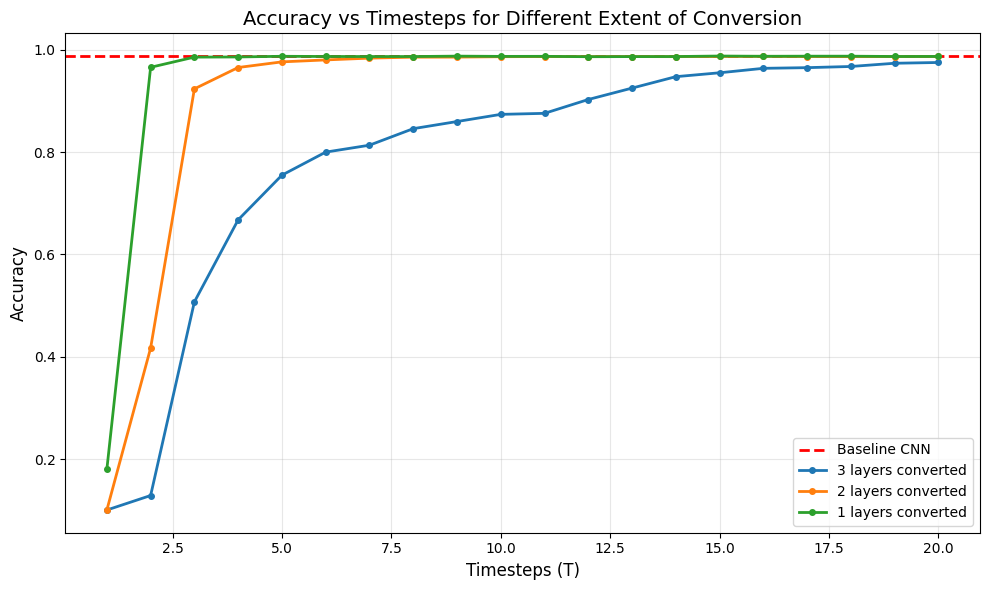

In [27]:
# Plot accuracy vs timesteps for all modes
plt.figure(figsize=(10, 6))
timesteps = range(1, snn.hyperparameters.T + 1)
plt.axhline(y=baseline_acc, color='red', linestyle='--', label="Baseline CNN", linewidth=2)
for layerCount, vals in acc.items():
    plt.plot(timesteps, vals, marker='o', label=(str(layerCount)+' layers converted'), linewidth=2, markersize=4)

plt.xlabel('Timesteps (T)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Timesteps for Different Extent of Conversion', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

SpikingJelly has changed the forward pass of the model significantly. 

In the framework the original Conv2d layer is used but only to simulate the scaling for the inputs to the IF neurons striped across time.
Hence we can use the number of spikes generated multiplied by the fan-out of the layer to estimate the number of accumulate operations (refer https://doi.org/10.3389/fnins.2017.00682)

We use val() in main() after conversion is complete. It evaluates the model on the train dataset and also registers a hook that stores spike counts of a IFNode layer in the model into snn.spike_counts. Dividing this by the size of the dataset provides an average for spike count per layer in a forward pass.

In [28]:
print(snn.spike_counts)

{'IFNode': 317653109.0}



Go to the file spikingjelly\activation_based\ann2snn\examples\cnn_mnist.py to see how snn.val() is defined

We use val() in main() after conversion is complete. It evaluates the model on the train dataset and also registers a hook that stores spike counts of a IFNode layer in the model into snn.spike_counts.

Write your own custom_val() functions so that you can register hooks to the IFNode() modules for storing spike counts into a dictionary/list for different converted models. (You should need to make minimal changes to val(). Printing a model out might help you figure out how to assign the right hooks.)


### Task 5 is getting average spike count in all layers for a forward pass of a fully converted SNN. (10 Marks)

For a fully converted SNN, use snn.main(custom_val, backbone = None, head = model.network).

Findings:
1. Counting spikes: attach hooks to each IF node,
2. Each IF node outputs, (Cout $\times$ OH $\times$ OW == #neurons) $\times$ batch_size
3. Getting the number of 1's in this tensor gives us the spikes for that time instant, this hook goes over all T-time steps.
4. By the end of $T^{th}$ step, inference is complete
5. As we go deeper, the number of neurons go down, consequently average spike count must decrease

As expected, 
Average number of spikes per input test image: (for 99.9%(max) - chosen design point)
- IFNode0 Spike Count: 16661.0626
- IFNode1 Spike Count: 5493.076
- IFNode2 Spike Count: 673.9729

Although (max) has a better sparsity, accuracy loss is greater.



In [29]:
def count_spikes_hook0(module, input, output):
    name = module.__class__.__name__ + '0'
    spike_counts_local[name] = spike_counts_local.get(name, 0) + output.sum().item()
def count_spikes_hook1(module, input, output):
    name = module.__class__.__name__ + '1'
    spike_counts_local[name] = spike_counts_local.get(name, 0) + output.sum().item()
def count_spikes_hook2(module, input, output):
    name = module.__class__.__name__ + '2'
    spike_counts_local[name] = spike_counts_local.get(name, 0) + output.sum().item()

def custom_val(net, device, train_data_loader, test_data_loader, T=None):
    # This eval_fn tests an SNN (or an ANN if T=None) on the test loader 
    # And registers a hook to store spike counts of first spiking layer into spike_counts

    # Try to make modified versions of this evaluation function to collect stats.
    # Make sure that in your code you only use test_data_loader to evaluate performance.
    # Use only train_data_loader to calculate stats of layers using hooks on their appropriate nodes.
    
    net.eval().to(device)
    correct = 0.0
    total = 0.0
    if T is not None:
        corrects = np.zeros(T)
    with torch.no_grad():
        for batch, (img, label) in enumerate(tqdm(test_data_loader)):
            img = img.to(device)
            if T is None:
                # not a spiking model
                out = net(img)  
                correct += (out.argmax(dim=1) == label.to(device)).float().sum().item()
            else:

                for m in net.modules():
                    if hasattr(m, 'reset'):
                        m.reset()
                for t in range(T):
                        
                    hooks=[count_spikes_hook0, count_spikes_hook1, count_spikes_hook2]
                    hook_nodes = [getattr(net, "").spiking0.if_node,
                                 getattr(net, "").spiking1.if_node,
                                 getattr(net, "").spiking2.if_node]
                    
                    handles = []
                    for hook, hook_node in zip(hooks, hook_nodes):
                        handles.append(hook_node.register_forward_hook(hook))

                    #forward pass
                    x = net(img)

                    for handle in handles:
                        handle.remove()

                    if t == 0:
                        out = x
                    else:
                        out += x
                    corrects[t] += (out.argmax(dim=1) == label.to(device)).float().sum().item()
            total += out.shape[0]

    return correct / total if T is None else corrects / total

In [30]:
snn.hyperparameters.T = 20
spike_counts_local = {}
snn_head, vals = snn.main(
    eval_fn = custom_val, 
    backbone = None, 
    head = model.network, 
    conversion = custom_conversion_job(1), 
    download_dataset = False,
    device = device_used,
    dataset_dir = dataset_dir)
print(spike_counts_local)

---------------------------------------------
Converting using 99.9% max(activation) as scales


100%|██████████| 600/600 [00:24<00:00, 24.59it/s]


Simulating...


100%|██████████| 100/100 [00:04<00:00, 23.51it/s]

{'IFNode0': 166610626.0, 'IFNode1': 54930760.0, 'IFNode2': 6739729.0}


Verifying the sparsity between various conversion modes

In [31]:
snn.hyperparameters.T = 20
for i in [0, 1, 2, 3]:
    print(f"\n{'='*60}")
    print(f"Running conversion with mode_sel={i} ({mode_names[i]})")
    spike_counts_local = {}
    snn_head, vals = snn.main(
        eval_fn = custom_val, 
        backbone = None, 
        head = model.network, 
        conversion = custom_conversion_job(i), 
        download_dataset = False,
        device = device_used,
        dataset_dir = dataset_dir)
    # printing firing rates
    test_data_count = 10000 # For MNIST
    tstep = snn.hyperparameters.T
    layer_name = ['IFNode0', 'IFNode1', 'IFNode2']
    print(f"Average number of spikes per input test image: ")
    for i in layer_name:
        print(f"{i} Spike Count: {spike_counts_local[i]/test_data_count}")
    print(f"{'-'*60}")
    fire_rate = {i : spike_counts_local[i]/(test_data_count*neurons[i]*tstep) for i in layer_name}
    for i in layer_name:
        print(f"{i} Fire Rate: {100*fire_rate[i]:.4f}%")
    
    print(f"{'-'*60}")
    print(f"Best Accuracy = {100*vals[-1]}%")


Running conversion with mode_sel=0 (max)
---------------------------------------------
Converting using max(activation) as scales


100%|██████████| 600/600 [00:06<00:00, 91.11it/s]


Simulating...


100%|██████████| 100/100 [00:04<00:00, 23.29it/s]


Average number of spikes per input test image: 
IFNode0 Spike Count: 5434.3751
IFNode1 Spike Count: 2936.5576
IFNode2 Spike Count: 531.4636
------------------------------------------------------------
IFNode0 Fire Rate: 1.2561%
IFNode1 Fire Rate: 3.7920%
IFNode2 Fire Rate: 9.2268%
------------------------------------------------------------
Best Accuracy = 85.1%

Running conversion with mode_sel=1 (99.9% max)
---------------------------------------------
Converting using 99.9% max(activation) as scales


...

Average number of spikes per input test image: 
IFNode0 Spike Count: 15576.4598
IFNode1 Spike Count: 7037.1726
IFNode2 Spike Count: 1032.7693
------------------------------------------------------------
IFNode0 Fire Rate: 3.6003%
IFNode1 Fire Rate: 9.0873%
IFNode2 Fire Rate: 17.9300%
------------------------------------------------------------
Best Accuracy = 96.87%

Running conversion with mode_sel=3 (1/4 max)
---------------------------------------------
Converting using 1/4 max(activation) as scales


100%|██████████| 600/600 [00:06<00:00, 91.40it/s]


Simulating...


100%|██████████| 100/100 [00:04<00:00, 23.50it/s]

Average number of spikes per input test image: 
IFNode0 Spike Count: 36002.8108
IFNode1 Spike Count: 11600.0933
IFNode2 Spike Count: 1697.2062
------------------------------------------------------------
IFNode0 Fire Rate: 8.3217%
IFNode1 Fire Rate: 14.9795%
IFNode2 Fire Rate: 29.4654%
------------------------------------------------------------
Best Accuracy = 97.6%


We observe that 99.9%(max) conversion offers the best accuracy for sparsity.

In [32]:
snn.hyperparameters.T = 20
spike_counts_local = {}
snn_head, vals = snn.main(
    eval_fn = custom_val, 
    backbone = None, 
    head = model.network, 
    conversion = custom_conversion_job(1), 
    download_dataset = False,
    device = device_used,
    dataset_dir = dataset_dir)
print(spike_counts_local)
############ plotting ######################
test_data_count = 10000 # For MNIST
tstep = snn.hyperparameters.T
layer_name = ['IFNode0', 'IFNode1', 'IFNode2']
print(f"Average number of spikes per input test image: ")
for i in layer_name:
    print(f"{i} Spike Count: {spike_counts_local[i]/test_data_count}")
print(f"{'-'*60}")
fire_rate = {i : spike_counts_local[i]/(test_data_count*neurons[i]*tstep) for i in layer_name}
for i in layer_name:
    print(f"{i} Fire Rate: {100*fire_rate[i]:.4f}%")

print(f"{'-'*60}")
print(f"Best Accuracy = {100*vals[-1]}%")

---------------------------------------------
Converting using 99.9% max(activation) as scales


100%|██████████| 600/600 [00:24<00:00, 24.16it/s]


Simulating...


100%|██████████| 100/100 [00:04<00:00, 23.63it/s]

{'IFNode0': 166610626.0, 'IFNode1': 54930760.0, 'IFNode2': 6739729.0}
Average number of spikes per input test image: 
IFNode0 Spike Count: 16661.0626
IFNode1 Spike Count: 5493.076
IFNode2 Spike Count: 673.9729
------------------------------------------------------------
IFNode0 Fire Rate: 3.8510%
IFNode1 Fire Rate: 7.0933%
IFNode2 Fire Rate: 11.7009%
------------------------------------------------------------
Best Accuracy = 97.48%


# Finding #ACs
1. #ACs(L+1) = {fire_rate(L) $\times$ weights} $\times$ every output neuron
2. #ACs(L+1) = fire_rate(L) $\times$ {C_in $\times$ kW $\times$ kH} $\times$ {C_out $\times$ oH $\times$ oW}
3. #ACs(L+1) = fire_rate(L) $\times$ #MACs(L+1)
This works out since #MACs(L+1) = fanout $\times$ #synaptic connections 

In [33]:
AC_count = {}
energy_savings = {}
snn_energy, ann_energy = 0, 0
for ix, i in enumerate(layer_name):
    if ix == 0:
        AC_count[i] = 0
        energy_savings[i] = 0
        snn_energy, ann_energy = MAC_count[i]*4.6, MAC_count[i]*4.6
    else:
        # accumulations is based on the fire rate of neurons 
        # of the previous layer
        AC_count[i] = fire_rate[layer_name[ix-1]]*MAC_count[i]*tstep
        energy_savings[i] = (MAC_count[i]*4.6 - AC_count[i]*0.6)/(MAC_count[i]*4.6)
        snn_energy += AC_count[i]*0.6
        ann_energy += MAC_count[i]*4.6

print(f"SNN Energy    : {snn_energy:.2f}nJ ")
print(f"ANN Energy    : {ann_energy:.2f}nJ ")
print(f"Net savings   :  {100*(ann_energy - snn_energy)/ann_energy:.2f}%")
for i in energy_savings:
    print(f"{'-'*60}")
    print(f"ACs Count     : {i}: {AC_count[i]} ")
    print(f"MACs Count    : {i}: {MAC_count[i]} ")
    print(f"Energy savings: {i}: {100*energy_savings[i]:.2f}% ")

SNN Energy    : 1481496.34nJ 
ANN Energy    : 6406732.80nJ 
Net savings   :  76.88%
------------------------------------------------------------
ACs Count     : IFNode0: 0 
MACs Count    : IFNode0: 194688 
Energy savings: IFNode0: 0.00% 
------------------------------------------------------------
ACs Count     : IFNode1: 858882.7063384616 
MACs Count    : IFNode1: 1115136 
Energy savings: IFNode1: 89.95% 
------------------------------------------------------------
ACs Count     : IFNode2: 117669.85943801655 
MACs Count    : IFNode2: 82944 
Energy savings: IFNode2: 81.50% 


In [34]:
print(snn_head)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=32, out_features=10, bias=True)
  (): Module(
    (voltage_hook_0): VoltageHook()
    (voltage_hook_1): VoltageHook()
    (voltage_hook_2): VoltageHook()
    (spiking0): Module(
      (scaler0): VoltageScaler(0.388821)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(2.571877)
    )
    (spiking1): Module(
      (scaler0): VoltageScaler(0.527687)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=

### Task 6 is reporting the best accuracy for an energy savings of 90% or higher. (15 Marks)

**Assume that energy cost of a MAC is 4.6nJ and cost of an accumulate op is 0.6nJ.** Using these values you can estimate the energy savings in converting a layer.

# ASSUMPTION
We ASSUME that the initial convolutional layer is not involved in the energy savings,
- Since in the given paper, the input to the first conv2d layer are FP32, but the outputs are time series spikes,
- Hence coming up with an "average spiking count" for the input images is not a good estimate.

In [35]:
test_data_count = 10000 # For MNIST
layer_name = ['IFNode0', 'IFNode1', 'IFNode2']

for tstep in [20, 19, 18, 17, 16, 15, 10, 5]:
    snn.hyperparameters.T = tstep
    print(f"{'='*60}")
    print(f"for T = {tstep}")
    spike_counts_local = {}
    snn_head, vals = snn.main(
        eval_fn = custom_val, 
        backbone = None, 
        head = model.network, 
        conversion = custom_conversion_job(1), 
        download_dataset = False,
        device = device_used,
        dataset_dir = dataset_dir)
    print(spike_counts_local)
    ############ plotting ######################
    test_data_count = 10000 # For MNIST
    tstep = snn.hyperparameters.T
    layer_name = ['IFNode0', 'IFNode1', 'IFNode2']
    print(f"{'-'*60}")
    fire_rate = {i : spike_counts_local[i]/(test_data_count*neurons[i]*tstep) for i in layer_name}
    for i in layer_name:
        print(f"{i} Fire Rate: {100*fire_rate[i]:.4f}%")
    
    print(f"{'-'*60}")
    print(f"Best Accuracy = {100*vals[-1]:.2f}%")
    
    AC_count = {}
    energy_savings = {}
    snn_energy, ann_energy = 0, 0
    for ix, i in enumerate(layer_name):
        if ix == 0:
            AC_count[i] = 0
            energy_savings[i] = 0
            snn_energy, ann_energy = MAC_count[i]*4.6, MAC_count[i]*4.6
        else:
            # accumulations is based on the fire rate of neurons 
            # of the previous layer
            AC_count[i] = fire_rate[layer_name[ix-1]]*MAC_count[i]*tstep
            energy_savings[i] = (MAC_count[i]*4.6 - AC_count[i]*0.6)/(MAC_count[i]*4.6)
            snn_energy += AC_count[i]*0.6
            ann_energy += MAC_count[i]*4.6
    
    print(f"SNN Energy    : {snn_energy:.2f}nJ ")
    print(f"ANN Energy    : {ann_energy:.2f}nJ ")
    print(f"Net savings   :  {100*(ann_energy - snn_energy)/ann_energy:.2f}%")
    print(f"Net IDEAL savings   :  {100*(ann_energy - snn_energy)/(ann_energy-MAC_count[layer_name[0]]*4.6):.2f}%")
    print(vals)


for T = 20
---------------------------------------------
Converting using 99.9% max(activation) as scales


100%|██████████| 600/600 [00:23<00:00, 25.75it/s]


Simulating...


100%|██████████| 100/100 [00:04<00:00, 23.60it/s]


{'IFNode0': 166610626.0, 'IFNode1': 54930760.0, 'IFNode2': 6739729.0}
------------------------------------------------------------
IFNode0 Fire Rate: 3.8510%
IFNode1 Fire Rate: 7.0933%
IFNode2 Fire Rate: 11.7009%
------------------------------------------------------------
Best Accuracy = 97.48%
SNN Energy    : 1481496.34nJ 
ANN Energy    : 6406732.80nJ 
Net savings   :  76.88%
Net IDEAL savings   :  89.37%
[0.101  0.1293 0.5074 0.6676 0.7548 0.7998 0.8133 0.8456 0.8595 0.8735
 0.8755 0.9025 0.9248 0.9471 0.9547 0.9634 0.9647 0.967  0.9733 0.9748]
for T = 19
---------------------------------------------
Converting using 99.9% max(activation) as scales


...

{'IFNode0': 57433299.0, 'IFNode1': 21680307.0, 'IFNode2': 3103142.0}
------------------------------------------------------------
IFNode0 Fire Rate: 2.6550%
IFNode1 Fire Rate: 5.5993%
IFNode2 Fire Rate: 10.7748%
------------------------------------------------------------
Best Accuracy = 87.35%
SNN Energy    : 1101072.48nJ 
ANN Energy    : 6406732.80nJ 
Net savings   :  82.81%
Net IDEAL savings   :  96.27%
[0.101  0.1293 0.5074 0.6676 0.7548 0.7998 0.8133 0.8456 0.8595 0.8735]
for T = 5
---------------------------------------------
Converting using 99.9% max(activation) as scales


100%|██████████| 600/600 [00:19<00:00, 31.09it/s]


Simulating...


100%|██████████| 100/100 [00:01<00:00, 51.28it/s]

{'IFNode0': 20844234.0, 'IFNode1': 6268696.0, 'IFNode2': 1004837.0}
------------------------------------------------------------
IFNode0 Fire Rate: 1.9272%
IFNode1 Fire Rate: 3.2380%
IFNode2 Fire Rate: 6.9780%
------------------------------------------------------------
Best Accuracy = 75.48%
SNN Energy    : 968093.47nJ 
ANN Energy    : 6406732.80nJ 
Net savings   :  84.89%
Net IDEAL savings   :  98.68%
[0.101  0.1293 0.5074 0.6676 0.7548]


The best accuracy for 90+%,
- Can be achieved by sweeping from T = 20 to T = 15,
- We observe that T = 19 gives us this

- Best Accuracy = 97.33%
- SNN Energy    : 1443895.43nJ 
- ANN Energy    : 6406732.80nJ 
- Net IDEAL savings   :  90.05%

### Task 7 is reporting the best energy savings you could achieve from ANN conversion for a loss in accuracy less than 5% from the original CNN. (15 Marks)


Remember, you can scale number of time steps (snn.hyperparameters.T) to scale both computation and accuracy.

Accuracy of SNN $\ge$ 98.7 - 5 = 93.7%
- T = 15 -> 95.47%
- T = 10 -> 85.35%

So need to iterate between those two.
- We find that T = 14 -> 94.71% accuracy, and 93.26% energy savings.

In [36]:
targetAccuracy = baseline_acc*100 - 5 # 93.7 %
test_data_count = 10000 # For MNIST
layer_name = ['IFNode0', 'IFNode1', 'IFNode2']

for tstep in [14, 13, 12, 11]:
    snn.hyperparameters.T = tstep
    print(f"{'='*60}")
    print(f"for T = {tstep}")
    spike_counts_local = {}
    snn_head, vals = snn.main(
        eval_fn = custom_val, 
        backbone = None, 
        head = model.network, 
        conversion = custom_conversion_job(1), 
        download_dataset = False,
        device = device_used,
        dataset_dir = dataset_dir)
    print(spike_counts_local)
    ############ plotting ######################
    test_data_count = 10000 # For MNIST
    tstep = snn.hyperparameters.T
    layer_name = ['IFNode0', 'IFNode1', 'IFNode2']
    print(f"{'-'*60}")
    fire_rate = {i : spike_counts_local[i]/(test_data_count*neurons[i]*tstep) for i in layer_name}
    for i in layer_name:
        print(f"{i} Fire Rate: {100*fire_rate[i]:.4f}%")
    
    print(f"{'-'*60}")
    print(f"Best Accuracy = {100*vals[-1]:.2f}%")
    
    AC_count = {}
    energy_savings = {}
    snn_energy, ann_energy = 0, 0
    for ix, i in enumerate(layer_name):
        if ix == 0:
            AC_count[i] = 0
            energy_savings[i] = 0
            snn_energy, ann_energy = MAC_count[i]*4.6, MAC_count[i]*4.6
        else:
            # accumulations is based on the fire rate of neurons 
            # of the previous layer
            AC_count[i] = fire_rate[layer_name[ix-1]]*MAC_count[i]*tstep
            energy_savings[i] = (MAC_count[i]*4.6 - AC_count[i]*0.6)/(MAC_count[i]*4.6)
            snn_energy += AC_count[i]*0.6
            ann_energy += MAC_count[i]*4.6
    
    print(f"SNN Energy    : {snn_energy:.2f}nJ ")
    print(f"ANN Energy    : {ann_energy:.2f}nJ ")
    print(f"Net savings   :  {100*(ann_energy - snn_energy)/ann_energy:.2f}%")
    print(f"Net IDEAL savings   :  {100*(ann_energy - snn_energy)/(ann_energy-MAC_count[layer_name[0]]*4.6):.2f}%")
    print(vals)



for T = 14
---------------------------------------------
Converting using 99.9% max(activation) as scales


100%|██████████| 600/600 [00:18<00:00, 32.89it/s]


Simulating...


100%|██████████| 100/100 [00:03<00:00, 30.47it/s]


{'IFNode0': 105242846.0, 'IFNode1': 35798010.0, 'IFNode2': 4616889.0}
------------------------------------------------------------
IFNode0 Fire Rate: 3.4751%
IFNode1 Fire Rate: 6.6038%
IFNode2 Fire Rate: 11.4506%
------------------------------------------------------------
Best Accuracy = 94.71%
SNN Energy    : 1267093.59nJ 
ANN Energy    : 6406732.80nJ 
Net savings   :  80.22%
Net IDEAL savings   :  93.26%
[0.101  0.1293 0.5074 0.6676 0.7548 0.7998 0.8133 0.8456 0.8595 0.8735
 0.8755 0.9025 0.9248 0.9471]
for T = 13
---------------------------------------------
Converting using 99.9% max(activation) as scales


...

{'IFNode0': 79153844.0, 'IFNode1': 29845462.0, 'IFNode2': 3932263.0}
------------------------------------------------------------
IFNode0 Fire Rate: 3.0493%
IFNode1 Fire Rate: 6.4234%
IFNode2 Fire Rate: 11.3781%
------------------------------------------------------------
Best Accuracy = 90.25%
SNN Energy    : 1178749.10nJ 
ANN Energy    : 6406732.80nJ 
Net savings   :  81.60%
Net IDEAL savings   :  94.86%
[0.101  0.1293 0.5074 0.6676 0.7548 0.7998 0.8133 0.8456 0.8595 0.8735
 0.8755 0.9025]
for T = 11
---------------------------------------------
Converting using 99.9% max(activation) as scales


100%|██████████| 600/600 [00:18<00:00, 32.27it/s]


Simulating...


100%|██████████| 100/100 [00:02<00:00, 34.32it/s]

{'IFNode0': 64029846.0, 'IFNode1': 24452001.0, 'IFNode2': 3496499.0}
------------------------------------------------------------
IFNode0 Fire Rate: 2.6909%
IFNode1 Fire Rate: 5.7410%
IFNode2 Fire Rate: 11.0369%
------------------------------------------------------------
Best Accuracy = 87.55%
SNN Energy    : 1125038.14nJ 
ANN Energy    : 6406732.80nJ 
Net savings   :  82.44%
Net IDEAL savings   :  95.84%
[0.101  0.1293 0.5074 0.6676 0.7548 0.7998 0.8133 0.8456 0.8595 0.8735
 0.8755]




So far we have used a really optimistic cost model which only considers energy required for compute operations; we have ignored the costs of writing our compute results to memory.
In reality activation maps are typically too large to fit entirely in CPU cache, especially in vision models. DRAM writes of a 64 byte vector are ~10-50nj and could easily be upwards of 100nj when activating different DRAM rows.

Efficient vision model pipelines try to take maximum advantage of tiling and operator fusion so that computation is focused on smaller regions of the activation map which can fit into cache memory. SRAM writes average around ~1-3nj per vector write across different levels, but this approach introduces a tradeoff between memory traffic and recomputation.

Assume you have a compute pipeline for vision models with high bandwidth memory where performing writes costs 25nj per 64 bytes on average across the available memory hierarchy. Ignore the costs of loading weights, hence only your activation maps contribute to memory-related energy costs. Treat the Conv2d, BatchNorm, ReLU and AvgPool operations within a block as fused for the purpose of memory accounting.



### Task 8 is calculating the memory-related energy costs of each layer in one forward pass of the CNN model. (5 Marks)

Assume these are also the memory-related energy cost of one timestep of running a converted SNN layer. Running the model for multiple time steps incurs this cost at each timestep.
- Re-using code from Task - 2, we store the output neuron/activation size after every fused block.

In [37]:
# TASK 2: number of mac operations in each convolutional layer
# Starting input size for MNIST
in_H, in_W = 28, 28
layer_name_cnn = ['Fused0', 'Fused1', 'Fused2']
out_activations = {}
for i, layer in enumerate(model.network):
    import math
    if isinstance(layer, nn.Conv2d):
        C_in  = layer.in_channels
        C_out = layer.out_channels
        kH, kW = layer.kernel_size
        sH, sW = layer.stride
        pH, pW = layer.padding
        # out size, since nn.Conv2d doesn't store in or out sizes
        out_H = math.floor((in_H - kH + 2 * pH) / sH) + 1
        out_W = math.floor((in_W - kW + 2 * pW) / sW) + 1
        in_H, in_W = out_H, out_W

    elif isinstance(layer, nn.AvgPool2d):
        # AvgPool changes size
        kH = layer.kernel_size
        sH = layer.stride
        pH = layer.padding

        in_H = math.floor((in_H - kH + 2 * pH) / sH) + 1
        in_W = math.floor((in_W - kH + 2 * pH) / sH) + 1
        out_activations[layer_name_cnn[i//4]] = in_H * in_W * C_out

print(out_activations)

{'Fused0': 5408, 'Fused1': 800, 'Fused2': 32}


In [38]:
# each activation is 4B, 16 of them make a "packet"
packet_size = (64 * 8)/ (4 * 8)
import math
mem_cost_cnn = {i : math.ceil(out_activations[i]/packet_size)*25 for i in layer_name_cnn}

for i in layer_name_cnn:
    print(f"{'='*60}")
    print(f"Memory write cost of {i} = {mem_cost_cnn[i]}nJ")
net_mem_cost_cnn = sum(mem_cost_cnn.values())

Memory write cost of Fused0 = 8450nJ
Memory write cost of Fused1 = 1250nJ
Memory write cost of Fused2 = 50nJ



### Task 9 is to report the best energy savings you could achieve from ANN conversion for a loss in accuracy less than 5% with the memory-aware cost model. (15 Marks)

This should highlight the importance of neuromorphic memory innovations like in-memory compute and asynchronous core design.


# Results
Best energy savings for less than 5% accuracy drop occurs at,
- T = 14,
- Best Accuracy = 94.71%
- Energy Savings (memory aware) = 93.42%

Assume write and read for every time-step,
- We would be storing storing a sparse binary activation output,
- under no optimization it would only take 1bit per activation,
- This gives a packet size of 512 (each write, writes 512 activations.)

In [41]:
# each activation is 1-bit, 512 of them make a "packet"
packet_size = (64 * 8)/ (1)
tstep = 14
import math
mem_cost_snn = {i : math.ceil(out_activations[i]/packet_size)*25 for i in layer_name_cnn}

for i in layer_name_cnn:
    print(f"{'='*60}")
    print(f"Memory write cost of {i} = {mem_cost_snn[i]}nJ")
net_mem_cost = sum(mem_cost_snn.values())

Memory write cost of Fused0 = 275nJ
Memory write cost of Fused1 = 50nJ
Memory write cost of Fused2 = 25nJ


In [42]:
targetAccuracy = baseline_acc*100 - 5 # 93.7 %
test_data_count = 10000 # For MNIST
layer_name = ['IFNode0', 'IFNode1', 'IFNode2']
tstep = 14
snn.hyperparameters.T = tstep
print(f"{'='*60}")
print(f"for T = {tstep}")
spike_counts_local = {}
snn_head, vals = snn.main(
    eval_fn = custom_val, 
    backbone = None, 
    head = model.network, 
    conversion = custom_conversion_job(1), 
    download_dataset = False,
    device = device_used,
    dataset_dir = dataset_dir)
print(spike_counts_local)
############ plotting ######################
test_data_count = 10000 # For MNIST
tstep = snn.hyperparameters.T
layer_name = ['IFNode0', 'IFNode1', 'IFNode2']
print(f"{'-'*60}")
fire_rate = {i : spike_counts_local[i]/(test_data_count*neurons[i]*tstep) for i in layer_name}
for i in layer_name:
    print(f"{i} Fire Rate: {100*fire_rate[i]:.4f}%")

print(f"{'-'*60}")
print(f"Best Accuracy = {100*vals[-1]:.2f}%")

AC_count = {}
energy_savings = {}
snn_energy, ann_energy = 0, 0
for ix, i in enumerate(layer_name):
    if ix == 0:
        AC_count[i] = 0
        energy_savings[i] = 0
        snn_energy, ann_energy = MAC_count[i]*4.6, MAC_count[i]*4.6
    else:
        # accumulations is based on the fire rate of neurons 
        # of the previous layer
        AC_count[i] = fire_rate[layer_name[ix-1]]*MAC_count[i]*tstep
        energy_savings[i] = (MAC_count[i]*4.6 - AC_count[i]*0.6)/(MAC_count[i]*4.6)
        snn_energy += AC_count[i]*0.6
        ann_energy += MAC_count[i]*4.6
ann_energy += net_mem_cost_cnn
snn_energy += net_mem_cost*tstep # since net_mem_cost is for one step only
print(f"SNN Energy        : {snn_energy:.2f}nJ ")
print(f"ANN Energy        : {ann_energy:.2f}nJ ")
print(f"Memory write cost : {net_mem_cost*tstep}nJ")
print(f"Net savings       :  {100*(ann_energy - snn_energy)/(ann_energy):.2f}%")
print(f"Net IDEAL savings :  {100*(ann_energy - snn_energy)/(ann_energy-MAC_count[layer_name[0]]*4.6):.2f}%")
print(vals)



for T = 14
---------------------------------------------
Converting using 99.9% max(activation) as scales


100%|██████████| 600/600 [00:18<00:00, 31.85it/s]


Simulating...


100%|██████████| 100/100 [00:03<00:00, 30.40it/s]

{'IFNode0': 105242846.0, 'IFNode1': 35798010.0, 'IFNode2': 4616889.0}
------------------------------------------------------------
IFNode0 Fire Rate: 3.4751%
IFNode1 Fire Rate: 6.6038%
IFNode2 Fire Rate: 11.4506%
------------------------------------------------------------
Best Accuracy = 94.71%
SNN Energy        : 1271993.59nJ 
ANN Energy        : 6416482.80nJ 
Memory write cost : 350nJ
Net savings       :  80.18%
Net IDEAL savings :  93.18%
[0.101  0.1293 0.5074 0.6676 0.7548 0.7998 0.8133 0.8456 0.8595 0.8735
 0.8755 0.9025 0.9248 0.9471]
